Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

Load Dataset

In [2]:
df = pd.read_csv("../data/processed/marketing_campaign_feature_engineered.csv")

Encode Categorical Columns

In [3]:
le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

Remove Unnecessary Columns

In [4]:
X = df.drop(columns=["ID", "Dt_Customer", "Response"])

Scale Data

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

K-Means

Elbow Method

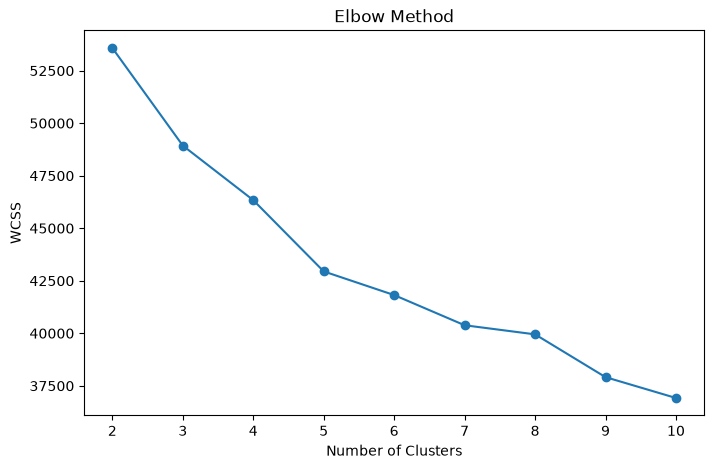

In [6]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

Train KMeans

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

Silhouette Score

In [8]:
score = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"]
)

print(score)

0.12005859085945679


DBSCAN

In [9]:
dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
-1    1426
 1     364
 0     223
 3     113
 2      56
 6      23
 5      13
 4       8
 9       5
 7       5
 8       4
Name: count, dtype: int64

PCA Visualization

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

KMeans Plot

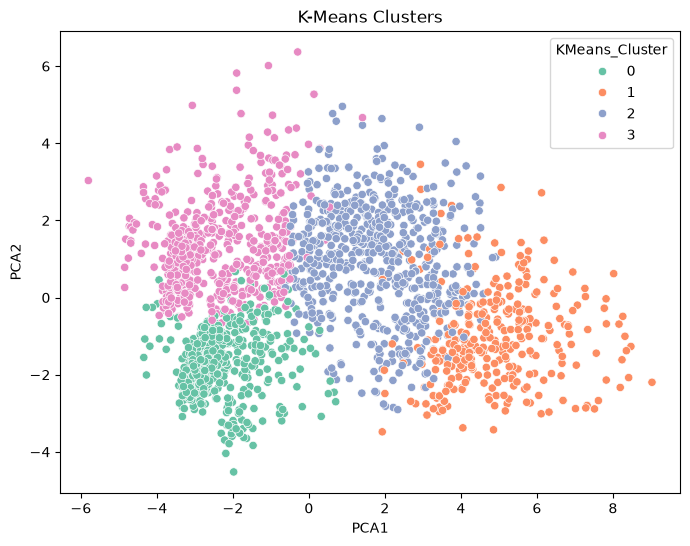

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    palette="Set2"
)

plt.title("K-Means Clusters")

plt.show()

DBSCAN Plot

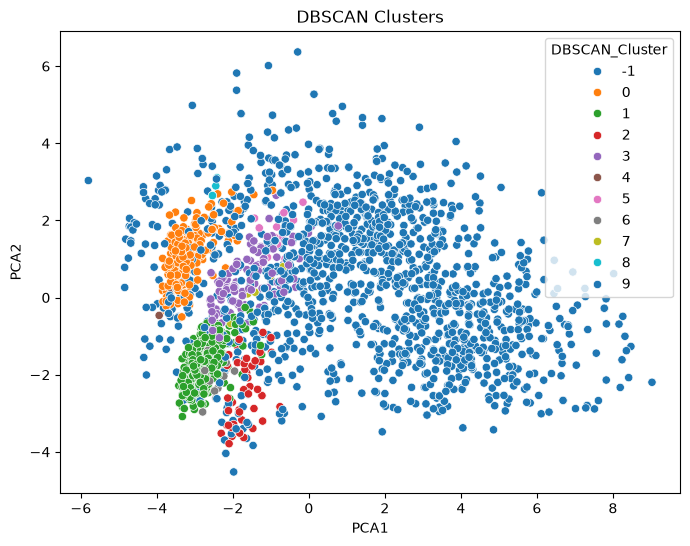

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("DBSCAN Clusters")

plt.show()

Customer Profiling

In [13]:
cluster_profile = df.groupby("KMeans_Cluster")[[
    "Income",
    "Age",
    "Total_Spending",
    "Total_Purchases"
]].mean()

cluster_profile

,Income,Age,Total_Spending,Total_Purchases
KMeans_Cluster,,,,
0,30772.725203,48.642276,105.390244,5.957724
1,81371.947143,55.102857,1570.445714,19.568571
2,63607.400298,61.575893,925.300595,18.866071
3,44549.725539,62.247098,200.190713,8.112769


Save Dataset

In [14]:
df.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)